In [2]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline


In [3]:
mouse = ctrl_mice[0]
day=2
sess = u.load_single_day(mouse, day, trial_mat_keys=['F_dff_nostop',], timeseries_keys=['F_dff_nostop',], verbose = False)

In [40]:
rows = []
for cond, mice in zip(('ctrl', 'ko'),(ctrl_mice,ko_mice)):
    for mouse in mice:
        print(mouse)
        for day in range(6):
            sess = u.load_single_day(mouse, day, trial_mat_keys=['F_dff_nostop',], timeseries_keys=['F_dff_nostop',], verbose = False)
            
            rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
            rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )

            if sess.novel_arm == 1: 
                rz_nov = rz_late
                rz_fam = rz_early
            else: 
                rz_nov = rz_early
                rz_fam = rz_late

            for ttype in ('nov', 'fam'):
                if ttype == 'nov':
                    rz = rz_nov
                    coef = 1
                    pc_mask = sess.nov_place_cell_mask()
                else:
                    rz = rz_fam
                    coef = -1 
                    pc_mask = sess.fam_place_cell_mask()

                tmat = sess.trial_matrices['F_dff_nostop'][sess.trial_info['LR']==coef*sess.novel_arm, :, :]
                tmat[np.isnan(tmat)]=0

                cell_corrs = []
                for cell in range(tmat.shape[-1]):
                    _mat = np.corrcoef(tmat[:,:,cell])
                    _mat[np.diag_indices_from(_mat)]=np.nan
                    cell_corrs.append(np.nanmean(_mat.ravel()))
                cell_corrs = np.array(cell_corrs)

                cell_pos = np.nanargmax(np.nanmean(sess.trial_matrices['F_dff_nostop'][sess.trial_info['LR']==coef*sess.novel_arm, :, :], axis=0),axis=0)
                
                r_mask = (cell_pos>=(rz[0]-5)) * (cell_pos<=(rz[0]+3))

                
                rows.append({'condition': cond,
                            'mouse': mouse,
                            'day': day,
                            'ttype': ttype,
                            'rzone_corr': np.nanmean(cell_corrs[r_mask*pc_mask]),
                            'nonrzone_corr': np.nanmean(cell_corrs[~r_mask])})
                
df = pd.DataFrame(rows)

4467331.1
4467331.2
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
4467332.1
4467332.2
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
4467333.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


mCherry6
mCherry7
mCherry8
mCherry9
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.2


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.3


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.4
4467975.5
Cre7
Cre9


In [41]:
df['rzone_corr_diff'] = df['rzone_corr']-df['nonrzone_corr']


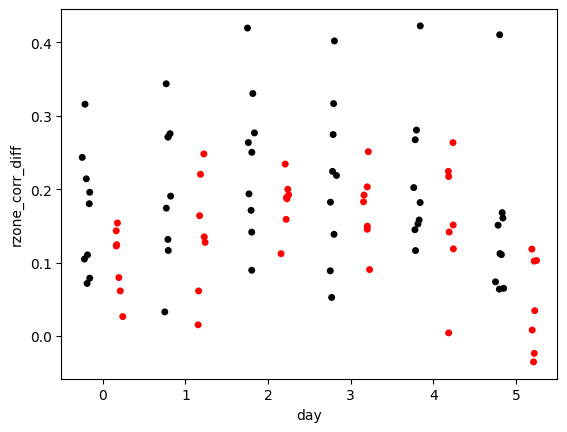

In [42]:
fig, ax = plt.subplots()

_ = sns.stripplot(data = df.loc[df['ttype']=='nov'],
                  x='day',
                  y = 'rzone_corr_diff',
                  hue = 'condition',
                  hue_order=['ctrl', 'ko'],
                  palette=['black','red'], 
                  dodge=True, ax=ax, legend=False)

In [ ]:
rows = []
for cond, mice in zip(('ctrl', 'ko'),(ctrl_mice,ko_mice)):
    for mouse in mice:
        print(mouse)
        for react_day in range(5):
            for tt_day in range(react_day+1,6):
                
            sess = u.load_single_day(mouse, day, trial_mat_keys=['F_dff_nostop',], timeseries_keys=['F_dff_nostop',], verbose = False)
            
            rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
            rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )

            if sess.novel_arm == 1: 
                rz_nov = rz_late
                rz_fam = rz_early
            else: 
                rz_nov = rz_early
                rz_fam = rz_late

            for ttype in ('nov', 'fam'):
                if ttype == 'nov':
                    rz = rz_nov
                    coef = 1
                    pc_mask = sess.nov_place_cell_mask()
                else:
                    rz = rz_fam
                    coef = -1 
                    pc_mask = sess.fam_place_cell_mask()

                tmat = sess.trial_matrices['F_dff_nostop'][sess.trial_info['LR']==coef*sess.novel_arm, :, :]
                tmat[np.isnan(tmat)]=0

                cell_corrs = []
                for cell in range(tmat.shape[-1]):
                    _mat = np.corrcoef(tmat[:,:,cell])
                    _mat[np.diag_indices_from(_mat)]=np.nan
                    cell_corrs.append(np.nanmean(_mat.ravel()))
                cell_corrs = np.array(cell_corrs)

                cell_pos = np.nanargmax(np.nanmean(sess.trial_matrices['F_dff_nostop'][sess.trial_info['LR']==coef*sess.novel_arm, :, :], axis=0),axis=0)
                
                r_mask = (cell_pos>=(rz[0]-5)) * (cell_pos<=(rz[0]+3))

                
                rows.append({'condition': cond,
                            'mouse': mouse,
                            'day': day,
                            'ttype': ttype,
                            'rzone_corr': np.nanmean(cell_corrs[r_mask*pc_mask]),
                            'nonrzone_corr': np.nanmean(cell_corrs[~r_mask])})
                
df = pd.DataFrame(rows)

611
0.35036618150316334 0.3908320625457773


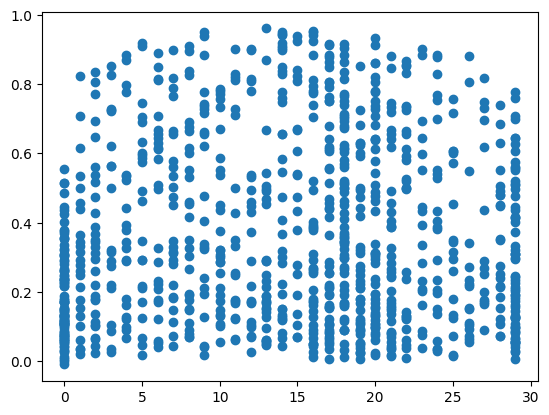